## Loan Default Analysis

Loan default analysis is about studying customer data to understand who is likely to fail to repay a loan.

Banks and financial institutions us this to:
- Reduce risk
- Decide who to give loans to
- Set interest rates


The main aim is:
To identify factors that influence whether a customer will default on a loan or not.

### OBJECTIVES

1. Understand the dataset(columns, values, missing data)
2. Identify patterns in customers who default
3. Compare defaulters vs non-defaulters
4. Find key risk factors(income, loan, amount, age, etc.)
5. Create visualizations to explain findings

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
data = pd.read_csv("Loan_Default.csv")

In [13]:
data.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [14]:
data.shape

(148670, 34)

In [15]:
data.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [17]:
data.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [18]:
data.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [19]:
data.dropna()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148665,173555,2019,cf,Sex Not Available,nopre,type1,p3,l1,nopc,nob/c,...,CIB,659,EXP,55-64,to_inst,71.792763,south,direct,0,48.0
148666,173556,2019,cf,Male,nopre,type1,p1,l1,nopc,nob/c,...,CIB,569,CIB,25-34,not_inst,74.428934,south,direct,0,15.0
148667,173557,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,CIB,702,EXP,45-54,not_inst,61.332418,North,direct,0,49.0
148668,173558,2019,cf,Female,nopre,type1,p4,l1,nopc,nob/c,...,EXP,737,EXP,55-64,to_inst,70.683453,North,direct,0,29.0


In [20]:
data.fillna(0, inplace=True)

In [21]:
data.shape

(148670, 34)

### EDA : Exploratory Data Analysis

In [29]:
# OBJ 1:  Understanding the Dataset

data.head()
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 148670 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              148670 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148670 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           148670 non-null  float64
 12  Interest_rate_spread       148670 non-null  float64
 13  Upfront_charges            14

ID                           0
year                         0
loan_limit                   0
Gender                       0
approv_in_adv                0
loan_type                    0
loan_purpose                 0
Credit_Worthiness            0
open_credit                  0
business_or_commercial       0
loan_amount                  0
rate_of_interest             0
Interest_rate_spread         0
Upfront_charges              0
term                         0
Neg_ammortization            0
interest_only                0
lump_sum_payment             0
property_value               0
construction_type            0
occupancy_type               0
Secured_by                   0
total_units                  0
income                       0
credit_type                  0
Credit_Score                 0
co-applicant_credit_type     0
age                          0
submission_of_application    0
LTV                          0
Region                       0
Security_Type                0
Status  

In [30]:
# Identify Target Variable
data["Status"].value_counts()

Status
0    112031
1     36639
Name: count, dtype: int64

In [31]:
# OBJ 2: Identify patterns in customers who default
data["Status"].value_counts(normalize=True)

Status
0    0.753555
1    0.246445
Name: proportion, dtype: float64

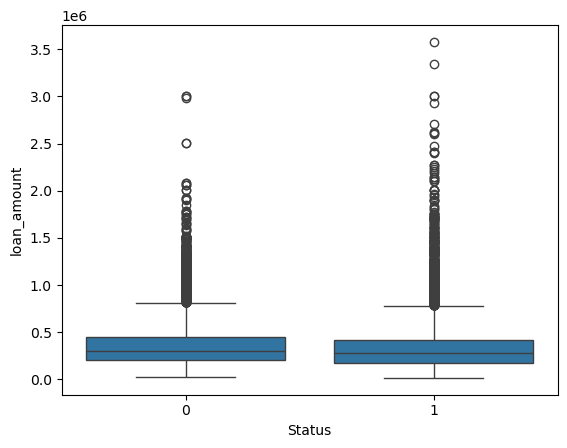

In [35]:
# OBJ 3: Find key risk factors(income, loan, amount, age, etc.). Comparing Defaulters vs Non-Defaulters
# Status vs Income
sns.boxplot(x="Status", y="loan_amount", data=data)
plt.show()

#### Interpretation
- Customers who default(Status = 1) tend to have higher loan amount compared to those who do not default.  
- The distribution of loan amount is higher for defaulters.

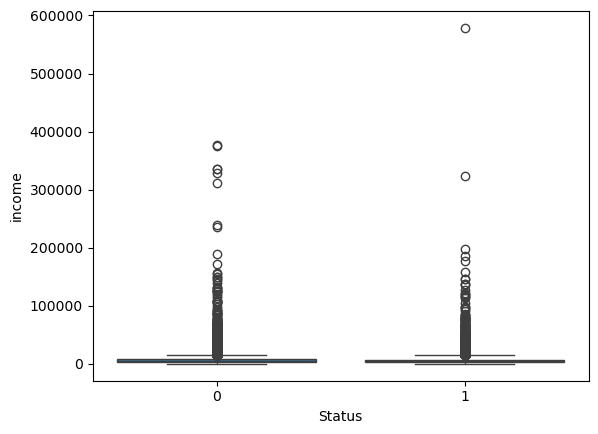

In [37]:
#  Status vs Income
sns.boxplot(x="Status", y="income", data=data)
plt.show()

#### Interpretation

Although some defaulters have high income, income alone does not fully explain default behaviour. Further analysis is required. 

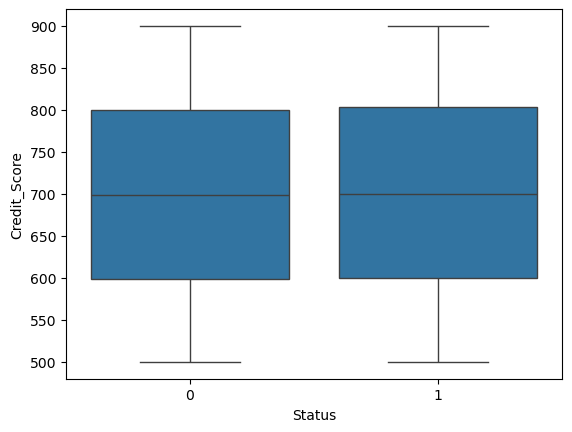

In [38]:
# Status vs Credit_Score
sns.boxplot(x="Status", y="Credit_Score", data=data)
plt.show()

#### Interpretation

The distribution of credit scores for defaulters and non-defaulters appears similar, suggesting that credit score alone may not strongly explain loan default in this dataset.

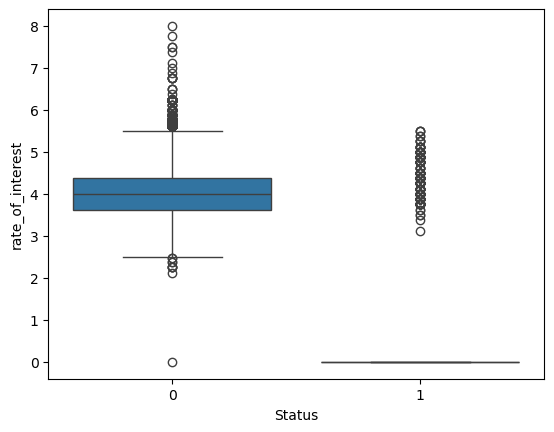

In [39]:
# Status vs Rate_of_interest
sns.boxplot(x="Status", y="rate_of_interest", data=data)
plt.show()

#### Interpretation
This shows that non-defaulters generally have higher interest rates than defaulters, suggesting that interest rate is a key risk factor in loan default.

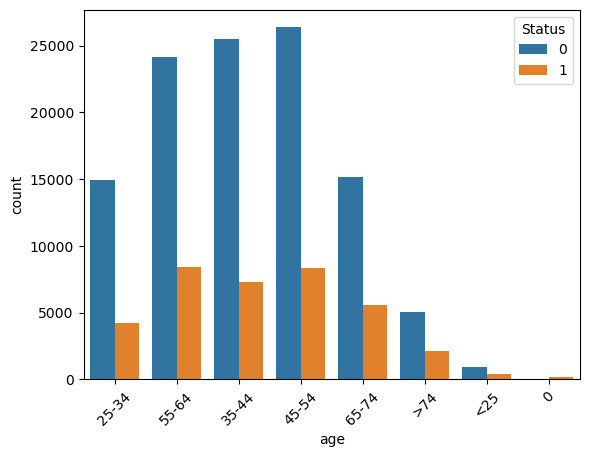

In [41]:
# Status vs Age
sns.countplot(x="age", hue="Status", data=data)
plt.xticks(rotation=45)
plt.show()

#### Interpretation

This shows that accross all age groups, non-defaulting borrowers consistently outnumber defaulting ones, suggesting that age alone may not be a strong predictor of default.

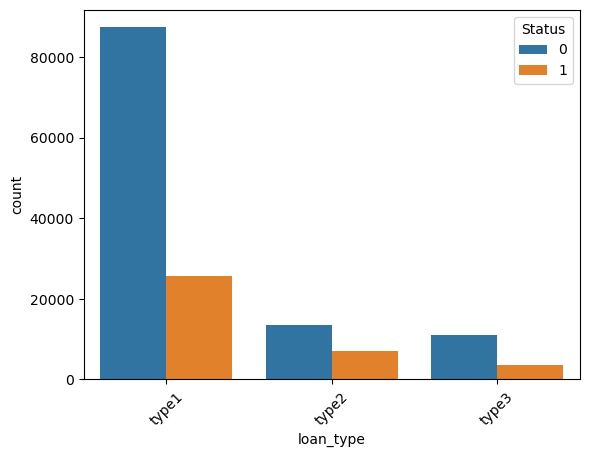

In [42]:
# Status vs loan_type
sns.countplot(x="loan_type", hue="Status", data=data)
plt.xticks(rotation=45)
plt.show()

#### Interpretation

This shows that across all loan types, non-defaulting borrowers indicating that loan type does not strongly affect repayment behaviour in this dataset. 

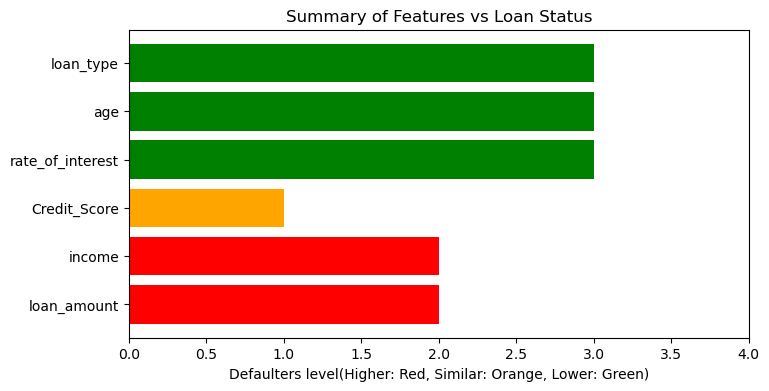

In [46]:
## Creating visualizations to explain findings
import matplotlib.pyplot as plt

# Features and their defaulter level
features = ['loan_amount', 'income', 'Credit_Score', 'rate_of_interest', 'age','loan_type']
defaulter_level = ['Higher', 'Higher', 'Similar', 'Lower', 'Lower', 'Lower']

# Map levels to numeric values for plotting
level_map = {'Higher': 2, 'Similar': 1, 'Lower': 3}
values = [level_map[level]  for level in defaulter_level]

# Colors for each level
color_map = {'Higher': 'red', 'Similar': 'orange', 'Lower': 'Green'}
colors = [color_map[level] for level in defaulter_level]

fig, ax = plt.subplots(figsize=(8,4))
ax.barh(features, values, color=colors)
ax.set_xlabel('Defaulters level(Higher: Red, Similar: Orange, Lower: Green)')
ax.set_title('Summary of Features vs Loan Status')
ax.set_xlim(0,4)

plt.show()

### Interpretation

The summary chart shows the relationship between borrower features and loan default. This visualization provides a clear, quick view of which factors are more likely to influence loan default.